# 05_Optimization

## Learning Goal
Studying Hessian, Fisher spectra, and Optimizer Dynamics.

## Prerequisites
Basic understanding of Calculus and Neural Networks.

## Theory & Mathematics
(Mathematical derivations and fundamental concepts)

## Implementation & Experiments


Total parameters (W): 41
Computing exact Hessian... (This may take a moment)
Max Eigenvalue: 1.2077e+01
Min Eigenvalue: 1.8909e-03
Condition Number: 6.3868e+03


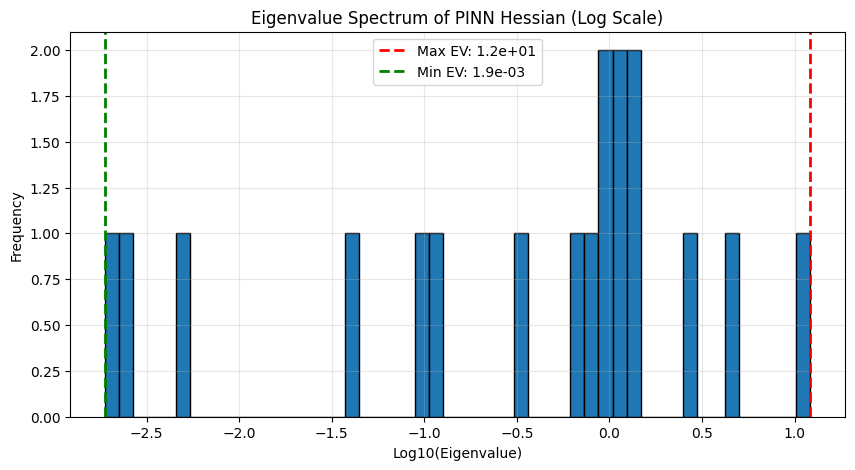

In [24]:
import torch
import torch.nn as nn
import torch.autograd as autograd
from torch.func import functional_call
import numpy as np
import matplotlib.pyplot as plt

# Ensure we are using the GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

# 1. Tiny PINN definition
class TinyPINN(nn.Module):
    def __init__(self):
        super(TinyPINN, self).__init__()
        self.fc1 = nn.Linear(2, 10)
        self.fc2 = nn.Linear(10, 1)
        self.act = nn.Tanh()
        
    def forward(self, x, t):
        z = torch.cat([x, t], dim=1)
        z = self.act(self.fc1(z))
        return self.fc2(z)

# 2. Derivative Computation using functional_call
# We use functional_call because it allows us to pass parameters as an argument 
# without breaking the computational graph, which is required for Hessian computation.
def compute_derivatives_func(model, params, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = functional_call(model, params, (x, t))
    
    u_x = autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_t = autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_xx = autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    return u, u_t, u_x, u_xx

# 3. Loss Function taking a flat parameter vector
def loss_fn_flat(theta_flat, model, param_names, shapes, x_ic, t_ic, u_ic, x_bc, t_bc, u_bc, x_f, t_f, nu):
    # Unflatten the 1D theta back into a dictionary of parameters
    params = {}
    idx = 0
    for name, shape in zip(param_names, shapes):
        numel = int(np.prod(shape))
        params[name] = theta_flat[idx:idx+numel].view(shape)
        idx += numel
        
    # Compute losses using functional_call
    u_pred_ic = functional_call(model, params, (x_ic, t_ic))
    loss_ic = torch.mean((u_pred_ic - u_ic)**2)
    
    u_pred_bc = functional_call(model, params, (x_bc, t_bc))
    loss_bc = torch.mean((u_pred_bc - u_bc)**2)
    
    u_pred_f, u_t, u_x, u_xx = compute_derivatives_func(model, params, x_f, t_f)
    residual = u_t + u_pred_f * u_x - nu * u_xx
    loss_pde = torch.mean(residual**2)
    
    return loss_ic + loss_bc + loss_pde

# 4. Setup
tiny_model = TinyPINN().to(device)
nu = 0.01 / np.pi

# Data (using very few points to keep Hessian computation fast)
x_ic = torch.rand(10, 1, device=device) * 2 - 1
t_ic = torch.zeros(10, 1, device=device)
u_ic = -torch.sin(np.pi * x_ic)

t_bc = torch.rand(10, 1, device=device)
x_bc = torch.where(torch.rand_like(t_bc) < 0.5, -torch.ones_like(t_bc), torch.ones_like(t_bc))
u_bc = torch.zeros(10, 1, device=device)

x_f = torch.rand(50, 1, device=device) * 2 - 1
t_f = torch.rand(50, 1, device=device)

# Extract parameter names and shapes
param_names = [name for name, _ in tiny_model.named_parameters()]
shapes = [p.shape for p in tiny_model.parameters()]

# Flatten initial parameters into a single 1D tensor
flat_params = torch.cat([p.view(-1) for p in tiny_model.parameters()]).clone().detach().requires_grad_(True)
W = flat_params.numel()
print(f"Total parameters (W): {W}")

# 5. Manual Hessian Computation via Double Backpropagation
print("Computing exact Hessian... (This may take a moment)")

# First, compute the loss and the gradient
loss = loss_fn_flat(flat_params, tiny_model, param_names, shapes, 
                    x_ic, t_ic, u_ic, x_bc, t_bc, u_bc, x_f, t_f, nu)

grad_loss = torch.autograd.grad(loss, flat_params, create_graph=True)[0]

# Initialize Hessian matrix
H = torch.zeros((W, W), device=device)

# Loop over each parameter to compute the second derivative
for i in range(W):
    # We only want the gradient of the i-th component of the gradient
    grad_outputs = torch.zeros_like(grad_loss)
    grad_outputs[i] = 1.0
    
    # Compute the second derivative: d(grad_loss[i]) / d(theta)
    hessian_row = torch.autograd.grad(grad_loss, flat_params, grad_outputs=grad_outputs, retain_graph=True)[0]
    H[i] = hessian_row

# 6. Eigenvalue Analysis
H_np = H.detach().cpu().numpy()
eigenvalues = np.linalg.eigvalsh(H_np)

# Filter out exact zeros (numerical noise) for log scale plotting
eigenvalues = eigenvalues[eigenvalues > 1e-12]

cond_number = np.max(eigenvalues) / np.min(eigenvalues)

print(f"Max Eigenvalue: {np.max(eigenvalues):.4e}")
print(f"Min Eigenvalue: {np.min(eigenvalues):.4e}")
print(f"Condition Number: {cond_number:.4e}")

# 7. Visualization
plt.figure(figsize=(10, 5))
plt.hist(np.log10(eigenvalues), bins=50, edgecolor='black')
plt.axvline(np.log10(np.max(eigenvalues)), color='r', linestyle='dashed', linewidth=2, label=f'Max EV: {np.max(eigenvalues):.1e}')
plt.axvline(np.log10(np.min(eigenvalues)), color='g', linestyle='dashed', linewidth=2, label=f'Min EV: {np.min(eigenvalues):.1e}')
plt.title('Eigenvalue Spectrum of PINN Hessian (Log Scale)')
plt.xlabel('Log10(Eigenvalue)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Computing Residual Jacobian (J)...
Computing Fisher Information Matrix (F = J^T J)...
Fisher Max EV: 3.2394e+00
Fisher Min EV: 3.2342e-11
Fisher Condition Number: 1.0016e+11


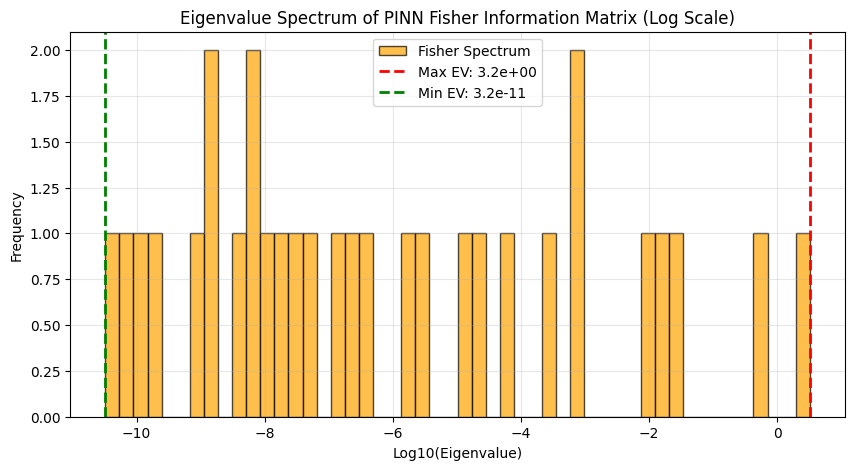

In [25]:
import torch
import torch.nn as nn
import torch.autograd as autograd
from torch.func import functional_call, vmap
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

# 1. Tiny PINN definition (Same as Milestone 2)
class TinyPINN(nn.Module):
    def __init__(self):
        super(TinyPINN, self).__init__()
        self.fc1 = nn.Linear(2, 10)
        self.fc2 = nn.Linear(10, 1)
        self.act = nn.Tanh()
        
    def forward(self, x, t):
        z = torch.cat([x, t], dim=1)
        z = self.act(self.fc1(z))
        return self.fc2(z)

# 2. Residual Function for a single point
def residual_single_point(model, params, x, t, nu):
    # Reshape to [1, 1] for batch processing in functional_call
    x_in = x.reshape(1, 1)
    t_in = t.reshape(1, 1)
    x_in.requires_grad_(True)
    t_in.requires_grad_(True)
    
    u = functional_call(model, params, (x_in, t_in))
    u_x = autograd.grad(u, x_in, torch.ones_like(u), create_graph=True)[0]
    u_t = autograd.grad(u, t_in, torch.ones_like(u), create_graph=True)[0]
    u_xx = autograd.grad(u_x, x_in, torch.ones_like(u_x), create_graph=True)[0]
    
    r = u_t + u * u_x - nu * u_xx
    return r.squeeze()

# 3. Setup
tiny_model = TinyPINN().to(device)
nu = 0.01 / np.pi

# Sample 50 collocation points
x_f = torch.rand(50, 1, device=device) * 2 - 1
t_f = torch.rand(50, 1, device=device)

# Extract parameter names and shapes, flatten them
param_names = [name for name, _ in tiny_model.named_parameters()]
shapes = [p.shape for p in tiny_model.parameters()]
flat_params = torch.cat([p.view(-1) for p in tiny_model.parameters()]).clone().detach().requires_grad_(True)
W = flat_params.numel()

# 4. Compute Jacobian of the Residual w.r.t Parameters
# We will use a loop for clarity, though vmap could parallelize this
print("Computing Residual Jacobian (J)...")
N_f = x_f.shape[0]
J = torch.zeros((N_f, W), device=device)

for i in range(N_f):
    # Compute residual for point i
    r_i = residual_single_point(tiny_model, 
                                {name: p.view(s) for name, p, s in zip(param_names, flat_params.split([int(np.prod(s)) for s in shapes]), shapes)}, 
                                x_f[i], t_f[i], nu)
    # Compute gradient of residual w.r.t flat_params
    grad_r = torch.autograd.grad(r_i, flat_params, retain_graph=True, create_graph=False)[0]
    J[i] = grad_r

# 5. Compute Fisher Information Matrix (Empirical)
print("Computing Fisher Information Matrix (F = J^T J)...")
F = (2.0 / N_f) * (J.T @ J)

# 6. Eigenvalue Analysis
F_np = F.detach().cpu().numpy()
fisher_eigenvalues = np.linalg.eigvalsh(F_np)
fisher_eigenvalues = fisher_eigenvalues[fisher_eigenvalues > 1e-12]

print(f"Fisher Max EV: {np.max(fisher_eigenvalues):.4e}")
print(f"Fisher Min EV: {np.min(fisher_eigenvalues):.4e}")
print(f"Fisher Condition Number: {np.max(fisher_eigenvalues) / np.min(fisher_eigenvalues):.4e}")

# 7. Visualization
plt.figure(figsize=(10, 5))
plt.hist(np.log10(fisher_eigenvalues), bins=50, edgecolor='black', color='orange', alpha=0.7, label='Fisher Spectrum')
plt.axvline(np.log10(np.max(fisher_eigenvalues)), color='r', linestyle='dashed', linewidth=2, label=f'Max EV: {np.max(fisher_eigenvalues):.1e}')
plt.axvline(np.log10(np.min(fisher_eigenvalues)), color='g', linestyle='dashed', linewidth=2, label=f'Min EV: {np.min(fisher_eigenvalues):.1e}')
plt.title('Eigenvalue Spectrum of PINN Fisher Information Matrix (Log Scale)')
plt.xlabel('Log10(Eigenvalue)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Training Adam only...
Training Adam -> L-BFGS...


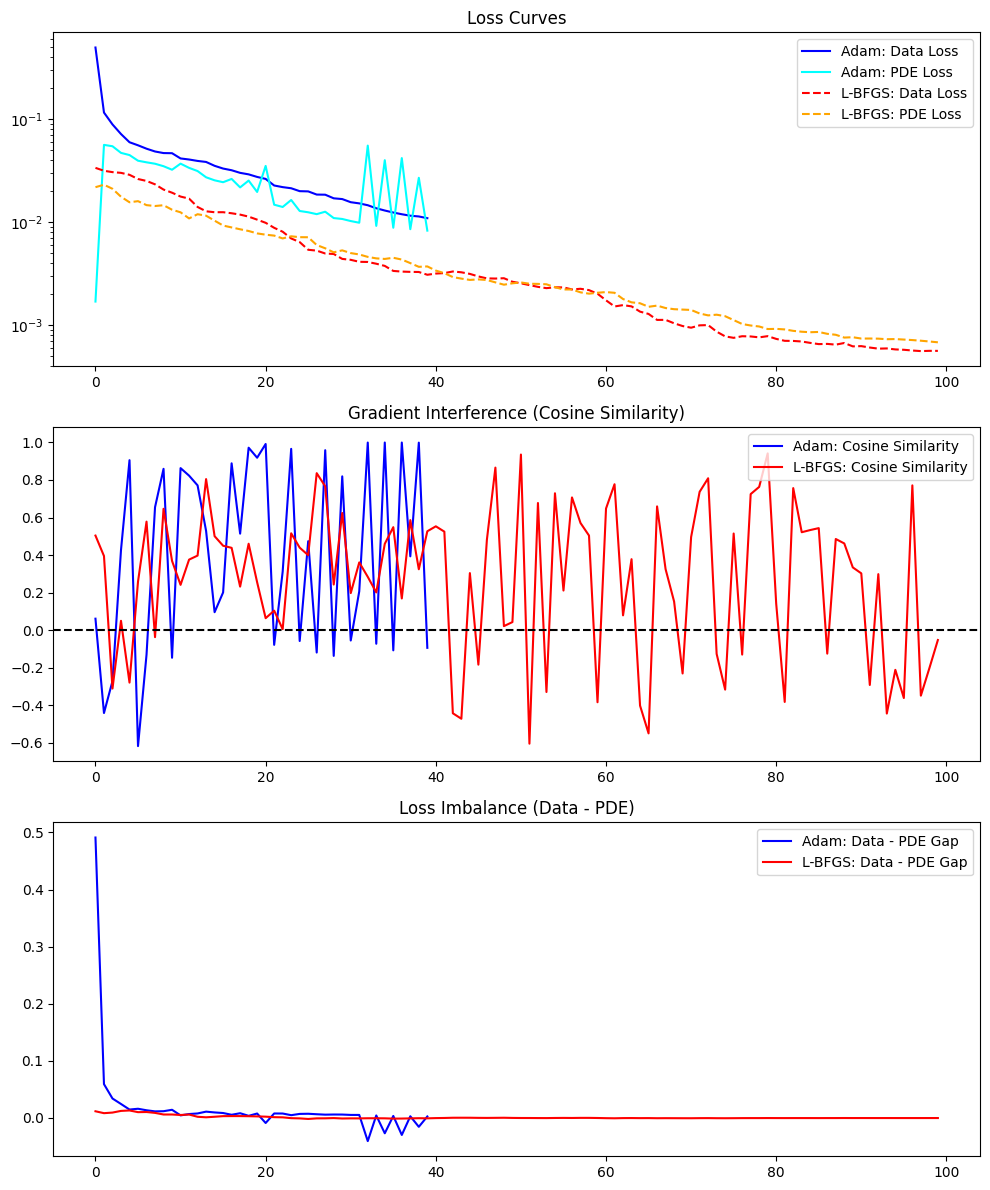

In [37]:
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

# 1. PINN definition
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 1)
        self.act = nn.Tanh()
        
    def forward(self, x, t):
        z = torch.cat([x, t], dim=1)
        z = self.act(self.fc1(z))
        z = self.act(self.fc2(z))
        z = self.act(self.fc3(z))
        return self.fc4(z)

def compute_derivatives(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_t = autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_xx = autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    return u, u_t, u_x, u_xx

def flatten_grads(model):
    grads = []
    for p in model.parameters():
        if p.grad is not None:
            grads.append(p.grad.view(-1))
    return torch.cat(grads)

# 2. Setup data
nu = 0.01 / np.pi
x_ic = torch.rand(200, 1, device=device) * 2 - 1
t_ic = torch.zeros(200, 1, device=device)
u_ic = -torch.sin(np.pi * x_ic)

t_bc = torch.rand(200, 1, device=device)
x_bc = torch.where(torch.rand_like(t_bc) < 0.5, -torch.ones_like(t_bc), torch.ones_like(t_bc))
u_bc = torch.zeros(200, 1, device=device)

x_f = torch.rand(1000, 1, device=device) * 2 - 1
t_f = torch.rand(1000, 1, device=device)

# Function to compute loss and gradients
def compute_loss_and_grads(model):
    model.zero_grad()
    
    # Data loss
    u_pred_ic = model(x_ic, t_ic)
    u_pred_bc = model(x_bc, t_bc)
    loss_data = torch.mean((u_pred_ic - u_ic)**2) + torch.mean((u_pred_bc - u_bc)**2)
    
    # PDE loss
    u_pred_f, u_t, u_x, u_xx = compute_derivatives(model, x_f, t_f)
    r = u_t + u_pred_f * u_x - nu * u_xx
    loss_pde = torch.mean(r**2)
    
    total_loss = loss_data + loss_pde
    
    # FIX: retain_graph=True is critical here because loss_pde shares the computational 
    # graph with loss_data. Without it, the graph is freed after total_loss.backward()
    total_loss.backward(retain_graph=True)
    
    g_data = flatten_grads(model).detach().clone()
    
    # We need to backward on pde alone to get its specific gradient vector
    model.zero_grad()
    loss_pde.backward()
    g_pde = flatten_grads(model).detach().clone()
    
    cos_sim = torch.dot(g_data, g_pde) / (torch.linalg.norm(g_data) * torch.linalg.norm(g_pde) + 1e-8)
    
    return loss_data.item(), loss_pde.item(), cos_sim.item()

# 3. Train function for a single optimizer strategy
def train_model(strategy):
    model = PINN().to(device)
    
    if strategy == 'adam_only':
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        epochs = 4000
        history = {'data': [], 'pde': [], 'cos_sim': []}
        
        for epoch in range(epochs):
            optimizer.zero_grad()
            u_pred_ic = model(x_ic, t_ic)
            u_pred_bc = model(x_bc, t_bc)
            u_pred_f, u_t, u_x, u_xx = compute_derivatives(model, x_f, t_f)
            
            loss_data = torch.mean((u_pred_ic - u_ic)**2) + torch.mean((u_pred_bc - u_bc)**2)
            r = u_t + u_pred_f * u_x - nu * u_xx
            loss_pde = torch.mean(r**2)
            
            total_loss = loss_data + loss_pde
            total_loss.backward()
            optimizer.step()
            
            if epoch % 100 == 0:
                ld, lp, cs = compute_loss_and_grads(model)
                history['data'].append(ld)
                history['pde'].append(lp)
                history['cos_sim'].append(cs)
        return history
        
    elif strategy == 'adam_then_lbfgs':
        # Phase 1: Adam
        optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
        for epoch in range(1500):
            optimizer_adam.zero_grad()
            u_pred_ic = model(x_ic, t_ic)
            u_pred_bc = model(x_bc, t_bc)
            u_pred_f, u_t, u_x, u_xx = compute_derivatives(model, x_f, t_f)
            loss_data = torch.mean((u_pred_ic - u_ic)**2) + torch.mean((u_pred_bc - u_bc)**2)
            r = u_t + u_pred_f * u_x - nu * u_xx
            loss_pde = torch.mean(r**2)
            (loss_data + loss_pde).backward()
            optimizer_adam.step()
            
        # Phase 2: L-BFGS
        optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.5, max_iter=20, 
                                           history_size=50, tolerance_grad=1e-7, 
                                           tolerance_change=1e-9)
        history = {'data': [], 'pde': [], 'cos_sim': []}
        
        # L-BFGS requires a closure function
        def closure():
            optimizer_lbfgs.zero_grad()
            u_pred_ic = model(x_ic, t_ic)
            u_pred_bc = model(x_bc, t_bc)
            u_pred_f, u_t, u_x, u_xx = compute_derivatives(model, x_f, t_f)
            loss_data = torch.mean((u_pred_ic - u_ic)**2) + torch.mean((u_pred_bc - u_bc)**2)
            r = u_t + u_pred_f * u_x - nu * u_xx
            loss_pde = torch.mean(r**2)
            loss = loss_data + loss_pde
            loss.backward()
            return loss
        
        # Run L-BFGS for 100 steps (each step does multiple iterations)
        for i in range(100):
            optimizer_lbfgs.step(closure)
            
            # Record metrics
            ld, lp, cs = compute_loss_and_grads(model)
            history['data'].append(ld)
            history['pde'].append(lp)
            history['cos_sim'].append(cs)
            
        return history

# 4. Run Experiments
print("Training Adam only...")
hist_adam = train_model('adam_only')

print("Training Adam -> L-BFGS...")
hist_lbfgs = train_model('adam_then_lbfgs')

# 5. Visualization
fig, axs = plt.subplots(3, 1, figsize=(10, 12))

axs[0].plot(hist_adam['data'], label='Adam: Data Loss', color='blue')
axs[0].plot(hist_adam['pde'], label='Adam: PDE Loss', color='cyan')
axs[0].plot(hist_lbfgs['data'], label='L-BFGS: Data Loss', color='red', linestyle='--')
axs[0].plot(hist_lbfgs['pde'], label='L-BFGS: PDE Loss', color='orange', linestyle='--')
axs[0].set_yscale('log')
axs[0].set_title('Loss Curves')
axs[0].legend()

axs[1].plot(hist_adam['cos_sim'], label='Adam: Cosine Similarity', color='blue')
axs[1].plot(hist_lbfgs['cos_sim'], label='L-BFGS: Cosine Similarity', color='red')
axs[1].axhline(0, color='black', linestyle='--')
axs[1].set_title('Gradient Interference (Cosine Similarity)')
axs[1].legend()

axs[2].plot([d - p for d, p in zip(hist_adam['data'], hist_adam['pde'])], label='Adam: Data - PDE Gap', color='blue')
axs[2].plot([d - p for d, p in zip(hist_lbfgs['data'], hist_lbfgs['pde'])], label='L-BFGS: Data - PDE Gap', color='red')
axs[2].set_title('Loss Imbalance (Data - PDE)')
axs[2].legend()

plt.tight_layout()
plt.show()

## Summary
This experiment demonstrates the specific concept in action.

## Further Reading
- Scientific Machine Learning & PINN surveys.